# AI Data Quality Monitor — Exploratory Analysis

This notebook is used to:
1. Explore the feature distributions from simulated events
2. Establish baseline statistics for drift detection
3. Visualize drift effects
4. Prototype and validate detection logic before deploying to Spark

In [1]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import jinja2

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Simulate Feature Data

In [2]:
DEVICE_TYPES = ['mobile', 'desktop', 'tablet']

def generate_normal_events(n=500):
    return pd.DataFrame([
        {
            'user_id': f'user_{random.randint(1, 100_000)}',
            'age': random.randint(18, 75),
            'purchase_amount': round(random.uniform(0.0, 500.0), 2),
            'session_duration': random.randint(30, 3600),
            'page_views': random.randint(1, 50),
            'device_type': random.choice(DEVICE_TYPES),
        }
        for _ in range(n)
    ])

def generate_drifted_events(n=500):
    """Simulates age shift + purchase amount spikes."""
    return pd.DataFrame([
        {
            'user_id': f'user_{random.randint(1, 100_000)}',
            'age': random.randint(65, 110),         # AGE DRIFT
            'purchase_amount': round(random.uniform(5000, 50000), 2),  # AMOUNT SPIKE
            'session_duration': random.randint(30, 3600),
            'page_views': random.randint(1, 50),
            'device_type': random.choice(DEVICE_TYPES + ['smartwatch', 'tv']),  # CAT DRIFT
        }
        for _ in range(n)
    ])

baseline_df = generate_normal_events(500)
drifted_df  = generate_drifted_events(500)

print(f'Baseline shape: {baseline_df.shape}')
print(f'Drifted shape:  {drifted_df.shape}')
baseline_df.head()

Baseline shape: (500, 6)
Drifted shape:  (500, 6)


,user_id,age,purchase_amount,session_duration,page_views,device_type
0,user_52182,42,144.49,1408,15,mobile
1,user_85913,64,136.13,2122,40,desktop
2,user_9344,35,3.03,3525,35,mobile
3,user_95057,49,192.15,92,45,mobile
4,user_80436,51,178.08,1346,31,desktop


## 2. Baseline Feature Statistics

In [3]:
baseline_df.describe()

,age,purchase_amount,session_duration,page_views
count,500.000000,500.000000,500.000000,500.000000
mean,45.798000,246.298240,1862.676000,25.662000
std,16.801004,148.212502,1019.848157,14.100404
min,18.000000,0.450000,39.000000,1.000000
25%,31.000000,122.347500,979.750000,14.000000
50%,45.000000,243.360000,1876.000000,26.000000
75%,61.000000,373.240000,2786.000000,37.000000
max,75.000000,499.530000,3597.000000,50.000000


## 3. Distribution Visualisation

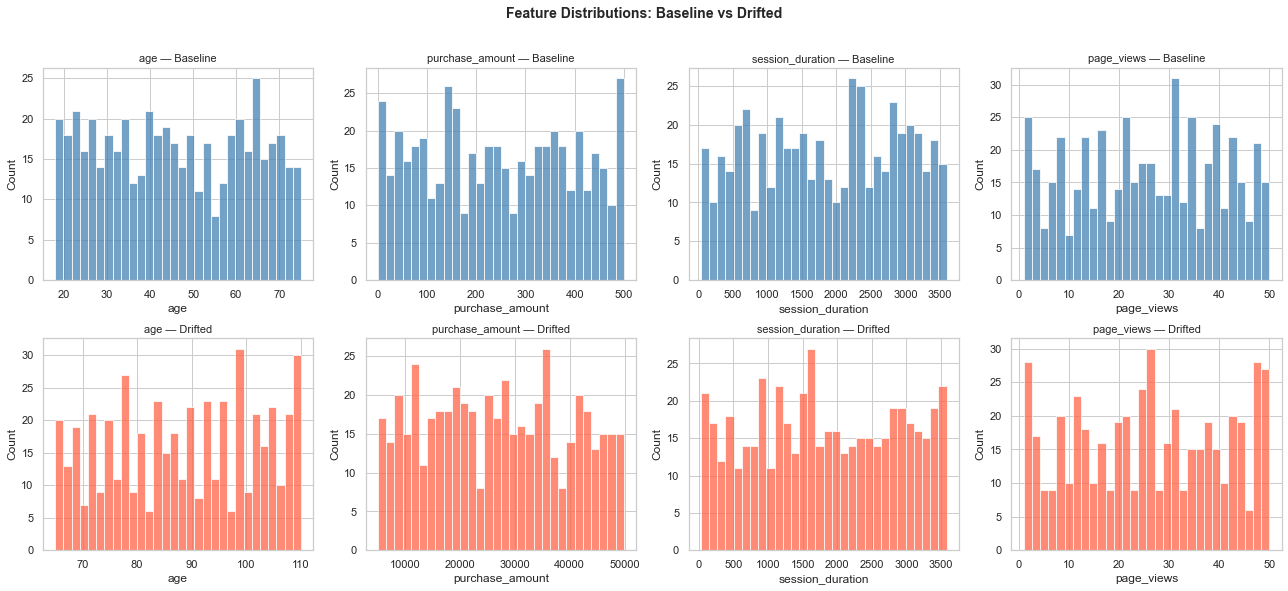

In [4]:
numeric_features = ['age', 'purchase_amount', 'session_duration', 'page_views']

fig, axes = plt.subplots(2, len(numeric_features), figsize=(18, 8))

for i, col in enumerate(numeric_features):
    # Baseline
    axes[0, i].hist(baseline_df[col].dropna(), bins=30, color='steelblue', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(f'{col} — Baseline', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Drifted
    axes[1, i].hist(drifted_df[col].dropna(), bins=30, color='tomato', alpha=0.75, edgecolor='white')
    axes[1, i].set_title(f'{col} — Drifted', fontsize=11)
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('Count')

plt.suptitle('Feature Distributions: Baseline vs Drifted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. KS Test — Drift Detection

In [ ]:
ks_results = []
for col in numeric_features:
    stat, p = stats.ks_2samp(baseline_df[col].dropna(), drifted_df[col].dropna())
    ks_results.append({
        'feature': col,
        'ks_statistic': round(stat, 4),
        'p_value': round(p, 6),
        'drifted': p < 0.05,
    })

ks_df = pd.DataFrame(ks_results)
ks_df.style.map(lambda v: 'background-color: #ffcccc' if v == True else '', subset=['drifted'])

## 5. Population Stability Index (PSI)

In [6]:
def compute_psi(reference, current, n_bins=10, epsilon=1e-4):
    bins = np.percentile(reference, np.linspace(0, 100, n_bins + 1))
    bins[0], bins[-1] = -np.inf, np.inf
    ref_pct = np.histogram(reference, bins=bins)[0] / len(reference) + epsilon
    cur_pct = np.histogram(current,   bins=bins)[0] / len(current)    + epsilon
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

psi_results = []
for col in numeric_features:
    psi = compute_psi(baseline_df[col].dropna().values, drifted_df[col].dropna().values)
    level = 'ALERT' if psi > 0.2 else ('WARNING' if psi > 0.1 else 'OK')
    psi_results.append({'feature': col, 'psi': round(psi, 4), 'level': level})

pd.DataFrame(psi_results)

,feature,psi,level
0,age,7.2236,ALERT
1,purchase_amount,8.2894,ALERT
2,session_duration,0.0317,OK
3,page_views,0.0312,OK


## 6. Null Rate Analysis

In [7]:
# Inject nulls into drifted set
drifted_with_nulls = drifted_df.copy()
null_mask = np.random.random(len(drifted_with_nulls)) < 0.15
drifted_with_nulls.loc[null_mask, 'age'] = np.nan

null_comparison = pd.DataFrame({
    'feature': baseline_df.columns,
    'baseline_null_rate': (baseline_df.isnull().mean() * 100).values,
    'current_null_rate': (drifted_with_nulls.isnull().mean() * 100).values,
})
null_comparison['delta_pp'] = (null_comparison['current_null_rate'] - null_comparison['baseline_null_rate']).round(2)
null_comparison['alert'] = null_comparison['delta_pp'].abs() > 5
null_comparison

,feature,baseline_null_rate,current_null_rate,delta_pp,alert
0,user_id,0.0,0.0,0.0,False
1,age,0.0,13.2,13.2,True
2,purchase_amount,0.0,0.0,0.0,False
3,session_duration,0.0,0.0,0.0,False
4,page_views,0.0,0.0,0.0,False
5,device_type,0.0,0.0,0.0,False


## 7. Categorical Feature Drift (Chi-Squared)

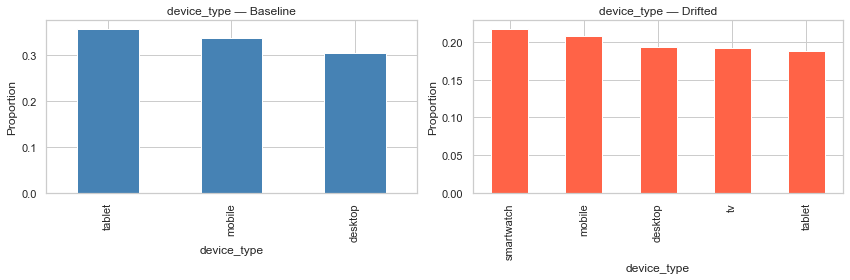

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1e-08, but the percent differences are:
0.00020000000000004546

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

baseline_df['device_type'].value_counts(normalize=True).plot.bar(ax=axes[0], color='steelblue', title='device_type — Baseline')
drifted_df['device_type'].value_counts(normalize=True).plot.bar(ax=axes[1], color='tomato', title='device_type — Drifted')

axes[0].set_ylabel('Proportion')
axes[1].set_ylabel('Proportion')
plt.tight_layout()
plt.show()

# Chi-squared test
all_cats = sorted(set(baseline_df['device_type']) | set(drifted_df['device_type']))
observed = [drifted_df['device_type'].value_counts().get(c, 0) for c in all_cats]
expected_freq = baseline_df['device_type'].value_counts(normalize=True)
expected = [expected_freq.get(c, 1e-4) * len(drifted_df) for c in all_cats]

chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)
print(f'Chi2={chi2:.4f}, p={p:.6f}, drifted={p < 0.05}')

## 8. RFF-MMD Drift Detection (Primary Method)

**Random Fourier Features Maximum Mean Discrepancy** is the primary drift detector used by the Spark streaming job.

Unlike KS/PSI which test features independently, RFF-MMD operates on the **joint feature distribution** — it detects subtle multi-variate shifts that univariate tests miss.

**How it works:**
1. **WARMUP** — fit an RFF projection on baseline data
2. **CALIBRATE** — score N windows of normal traffic to set the 99th-percentile threshold
3. **MONITORING** — every new window gets an MMD² score; if it exceeds the threshold, drift is flagged

```
z(x) = √(2/D) · cos(ωᵀx + b),   ω ~ N(0, 1/σ²),  b ~ U(0, 2π)
MMD² ≈ ‖ mean_z(baseline) − mean_z(current) ‖²
```

Complexity: **O(n·D)** vs naive kernel MMD's O(n²).

In [ ]:
# ── Standalone RFF-MMD Detector (mirrors streaming_job/drift.py, no PySpark) ──

class RFFMMDDetector:
    """
    Random Fourier Features approximation of Maximum Mean Discrepancy.
    Fits on a baseline distribution; .score() returns an MMD² estimate.
    """
    def __init__(self, n_components=200, sigma=None, calibration_percentile=99.0, random_state=42):
        self.n_components = n_components
        self.sigma = sigma
        self.calibration_percentile = calibration_percentile
        self.rng = np.random.RandomState(random_state)
        self.omega_ = self.bias_ = self.baseline_mean_ = self.threshold_ = None
        self.is_fitted = False

    def _median_heuristic(self, X):
        n = min(500, len(X))
        idx = self.rng.choice(len(X), n, replace=False)
        s = X[idx]
        sq = np.sum((s[:, None] - s[None, :]) ** 2, axis=-1)
        pos = sq[sq > 0]
        return float(np.sqrt(np.median(pos) / 2)) if len(pos) > 0 else 1.0

    def _transform(self, X):
        return np.cos(X @ self.omega_.T + self.bias_) * np.sqrt(2.0 / self.n_components)

    def fit(self, baseline):
        n_features = baseline.shape[1]
        if self.sigma is None:
            self.sigma = self._median_heuristic(baseline)
        self.omega_ = self.rng.normal(0, 1.0 / self.sigma, (self.n_components, n_features))
        self.bias_  = self.rng.uniform(0, 2 * np.pi, self.n_components)
        self.baseline_mean_ = self._transform(baseline).mean(axis=0)
        self.is_fitted = True
        print(f"✓ RFF-MMD fitted  | samples={len(baseline)}  features={n_features}  σ={self.sigma:.4f}  D={self.n_components}")
        return self

    def score(self, current):
        mu = self._transform(current).mean(axis=0)
        return float(np.sum((mu - self.baseline_mean_) ** 2))

    def calibrate(self, scores):
        self.threshold_ = float(np.percentile(scores, self.calibration_percentile))
        print(f"✓ Threshold set   | {self.calibration_percentile}th pct of {len(scores)} scores → {self.threshold_:.6f}")
        return self.threshold_

    def is_drift(self, score):
        return score > self.threshold_


NUMERIC_FEATURES = ['age', 'purchase_amount', 'session_duration', 'page_views']

def to_matrix(df):
    return df[NUMERIC_FEATURES].dropna().values.astype(float)


# ─── Phase 1: WARMUP — fit detector on baseline data ──────────────────────────
print("═" * 55)
print("  Phase 1 · WARMUP")
print("═" * 55)
detector = RFFMMDDetector(n_components=200, calibration_percentile=99.0)
detector.fit(to_matrix(baseline_df))

# ─── Phase 2: CALIBRATE — score 8 normal windows to set threshold ─────────────
print("\n" + "═" * 55)
print("  Phase 2 · CALIBRATE")
print("═" * 55)
cal_scores = []
for i in range(8):
    w = generate_normal_events(300)
    s = detector.score(to_matrix(w))
    cal_scores.append(s)
    print(f"  window {i+1}/8  MMD²={s:.6f}")

threshold = detector.calibrate(cal_scores)

# ─── Phase 3: MONITORING — score a normal and a drifted window ────────────────
print("\n" + "═" * 55)
print("  Phase 3 · MONITORING")
print("═" * 55)
normal_score  = detector.score(to_matrix(generate_normal_events(300)))
drifted_score = detector.score(to_matrix(drifted_df))

print(f"\n  Normal window   MMD²={normal_score:.6f}  drift={detector.is_drift(normal_score)}")
print(f"  Drifted window  MMD²={drifted_score:.6f}  drift={detector.is_drift(drifted_score)}")
print(f"\n  Separation: drifted score is {drifted_score/threshold:.0f}× above the threshold")

In [ ]:
# ── Visualisation 1: Score timeline + distribution ───────────────────────────
normal_scores  = [detector.score(to_matrix(generate_normal_events(300)))  for _ in range(20)]
drifted_scores = [detector.score(to_matrix(generate_drifted_events(300))) for _ in range(20)]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Left: score per window
x = range(1, 21)
axes[0].plot(x, normal_scores,  'o-', color='steelblue', label='Normal',  linewidth=1.5, markersize=5)
axes[0].plot(x, drifted_scores, 's-', color='tomato',    label='Drifted', linewidth=1.5, markersize=5)
axes[0].axhline(threshold, color='orange', linestyle='--', linewidth=2,
                label=f'Threshold = {threshold:.5f}')
axes[0].fill_between(x, threshold, max(drifted_scores)*1.05, alpha=0.07, color='tomato')
axes[0].set_title('RFF-MMD² Score per Window', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Window index')
axes[0].set_ylabel('MMD² Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: score distribution
axes[1].hist(normal_scores,  bins=8, color='steelblue', alpha=0.75, label='Normal',  edgecolor='white')
axes[1].hist(drifted_scores, bins=8, color='tomato',    alpha=0.75, label='Drifted', edgecolor='white')
axes[1].axvline(threshold, color='orange', linestyle='--', linewidth=2,
                label=f'Threshold = {threshold:.5f}')
axes[1].set_title('Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('MMD² Score')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RFF-MMD: Normal vs Drifted Windows', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Normal   — mean={np.mean(normal_scores):.6f}  max={np.max(normal_scores):.6f}")
print(f"Drifted  — mean={np.mean(drifted_scores):.6f}  min={np.min(drifted_scores):.6f}")
print(f"All {sum(s > threshold for s in drifted_scores)}/20 drifted windows correctly flagged")
print(f"All {sum(s <= threshold for s in normal_scores)}/20 normal windows correctly passed")


# ── Visualisation 2: Per-feature MMD contribution (ablation) ─────────────────
feature_scores = {}
for feat in NUMERIC_FEATURES:
    d = RFFMMDDetector(n_components=200)
    b1d = baseline_df[[feat]].dropna().values.astype(float)
    c1d = drifted_df[[feat]].dropna().values.astype(float)
    d.fit(b1d)
    feature_scores[feat] = d.score(c1d)

fig, ax = plt.subplots(figsize=(8, 3.5))
feats  = list(feature_scores.keys())
scores = list(feature_scores.values())
max_s  = max(scores)
colors = ['tomato' if s == max_s else 'steelblue' for s in scores]
bars   = ax.barh(feats, scores, color=colors, edgecolor='white', height=0.5)
for bar, s in zip(bars, scores):
    ax.text(bar.get_width() + max_s * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{s:.5f}', va='center', fontsize=10)
ax.set_title('Per-Feature MMD² Contribution (Drifted vs Baseline)', fontsize=12, fontweight='bold')
ax.set_xlabel('MMD² Score (higher = more drift)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary Dashboard

In [ ]:
print('=' * 55)
print('  DATA QUALITY & DRIFT SUMMARY')
print('=' * 55)

print('\n[RFF-MMD — Primary Drift Detector]')
print(f"  Threshold (99th pct, {len(cal_scores)} calibration windows): {threshold:.6f}")
print(f"  Normal  window score : {normal_score:.6f}  → {'⚠ DRIFT' if detector.is_drift(normal_score) else '✓ OK'}")
print(f"  Drifted window score : {drifted_score:.6f}  → {'⚠ DRIFT' if detector.is_drift(drifted_score) else '✓ OK'}")
print(f"  Top drifting feature : {max(feature_scores, key=feature_scores.get)} (MMD²={max(feature_scores.values()):.5f})")

print('\n[KS Test Results]')
for r in ks_results:
    status = '⚠ DRIFT' if r['drifted'] else '✓ OK'
    print(f"  {r['feature']:20s} ks={r['ks_statistic']:.4f}  p={r['p_value']:.6f}  {status}")

print('\n[PSI Results]')
for r in psi_results:
    print(f"  {r['feature']:20s} psi={r['psi']:.4f}  [{r['level'].upper()}]")

print('=' * 55)